# Phase 1: Basic Visualizations (Y1-01 to Y1-03)

**Assignment:** DAT2061 COVID-19 Data Visualization

**Phase 1 Objectives:**
- Y1-01: Distribution analysis (histogram, box plot, density)
- Y1-02: Time series plots
- Y1-03: Trend and recovery analysis

**Data Source:** data/processed/covid_cleaned.csv

## Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Output directory
OUTPUT_DIR = '../../outputs/visualizations/phase1/'

print("Setup complete!")

Setup complete!


## Load Processed Data

In [6]:
# Load processed data from ETL pipeline
df = pd.read_csv('../../data/processed/covid_cleaned.csv')
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'])

print(f"Loaded {len(df)} records")
print(f"Date range: {df['ObservationDate'].min()} to {df['ObservationDate'].max()}")
print(f"Countries: {df['Country/Region'].nunique()}")
df.head()

Loaded 306429 records
Date range: 2020-01-22 00:00:00 to 2021-05-29 00:00:00
Countries: 224


,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,Active,DeathRate,RecoveryRate,ActiveRate,DailyConfirmed,DailyDeaths,DailyRecovered,IsOutlier,IsHighValue
0,2325,2020-02-24,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
1,2420,2020-02-25,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
2,2523,2020-02-26,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
3,2629,2020-02-27,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False
4,2739,2020-02-28,National,Afghanistan,NaN,1,0,0,1,0.0,0.0,100.0,0.0,0.0,0.0,False,False


---
# Y1-01: Distribution Analysis

**Objective:** Understand distribution of infection counts using histogram, box plot, and density plot

## 1.1 Histogram - Confirmed Cases Distribution

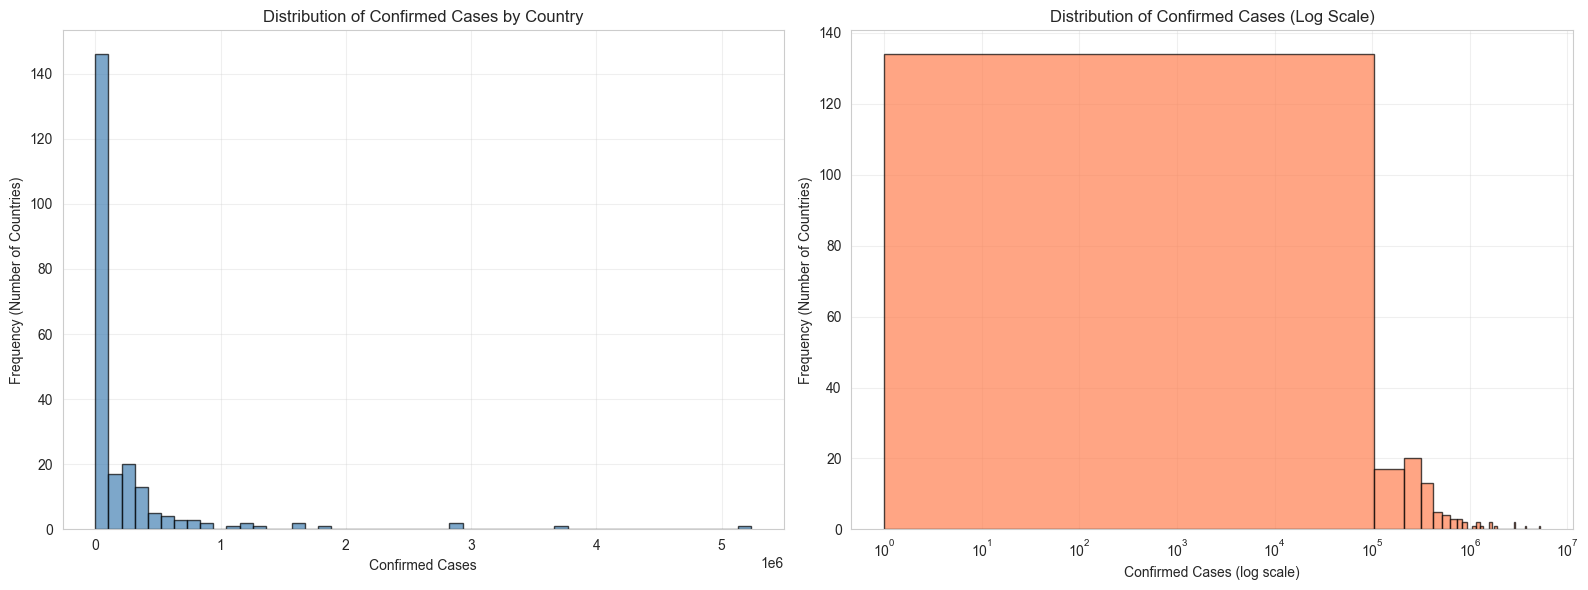

Mean: 225,368
Median: 29,549
Std Dev: 567,692


In [7]:
# Get latest data per country
latest_data = df.groupby('Country/Region').last().reset_index()

# Create histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regular scale
axes[0].hist(latest_data['Confirmed'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Confirmed Cases')
axes[0].set_ylabel('Frequency (Number of Countries)')
axes[0].set_title('Distribution of Confirmed Cases by Country')
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].hist(latest_data['Confirmed'][latest_data['Confirmed'] > 0], bins=50, 
             color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Confirmed Cases (log scale)')
axes[1].set_ylabel('Frequency (Number of Countries)')
axes[1].set_title('Distribution of Confirmed Cases (Log Scale)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_01_histogram_confirmed.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean: {latest_data['Confirmed'].mean():,.0f}")
print(f"Median: {latest_data['Confirmed'].median():,.0f}")
print(f"Std Dev: {latest_data['Confirmed'].std():,.0f}")

## 1.2 Box Plot - Outlier Detection

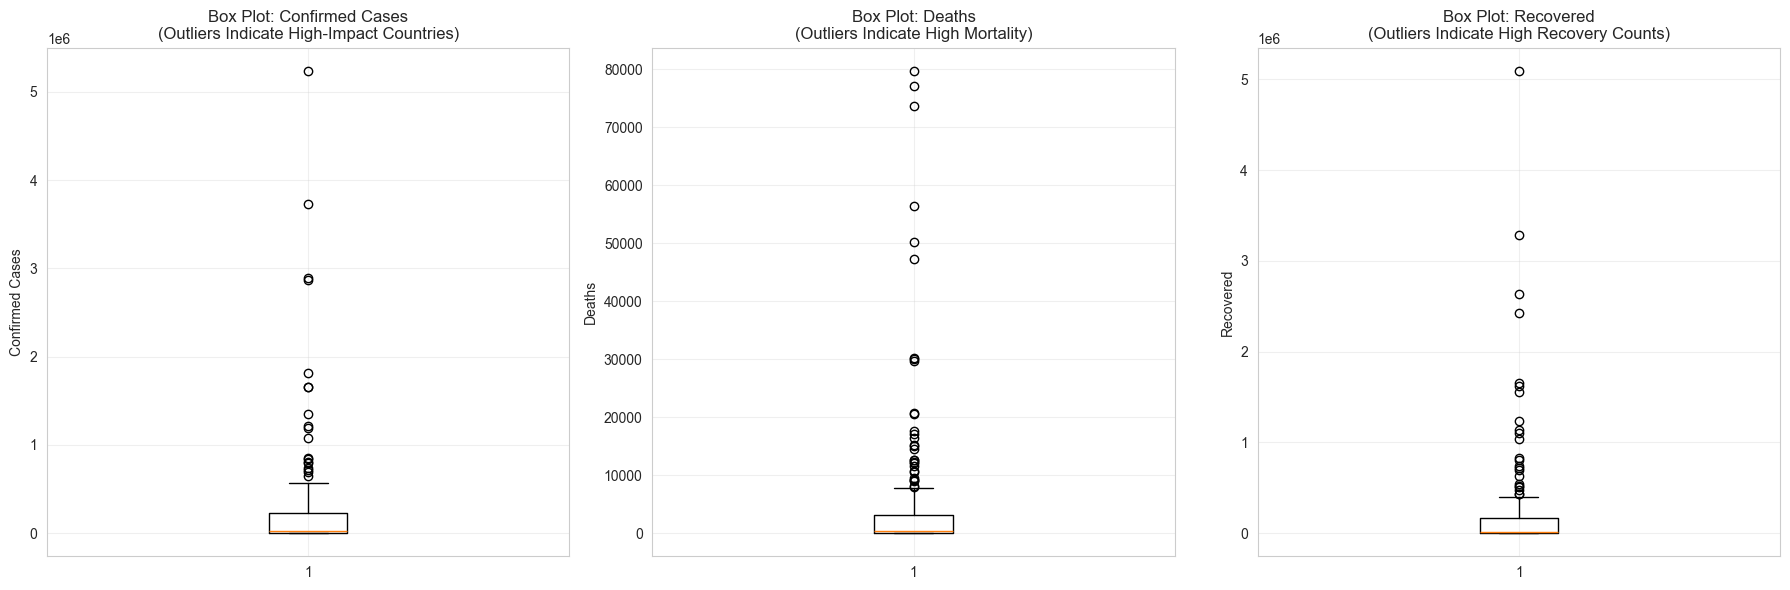

In [8]:
# Box plot for confirmed, deaths, recovered
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Confirmed cases
axes[0].boxplot(latest_data['Confirmed'], vert=True)
axes[0].set_ylabel('Confirmed Cases')
axes[0].set_title('Box Plot: Confirmed Cases\n(Outliers Indicate High-Impact Countries)')
axes[0].grid(True, alpha=0.3)

# Deaths
axes[1].boxplot(latest_data['Deaths'], vert=True)
axes[1].set_ylabel('Deaths')
axes[1].set_title('Box Plot: Deaths\n(Outliers Indicate High Mortality)')
axes[1].grid(True, alpha=0.3)

# Recovered
axes[2].boxplot(latest_data['Recovered'], vert=True)
axes[2].set_ylabel('Recovered')
axes[2].set_title('Box Plot: Recovered\n(Outliers Indicate High Recovery Counts)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_01_boxplot_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.3 Density Plot - Probability Distribution

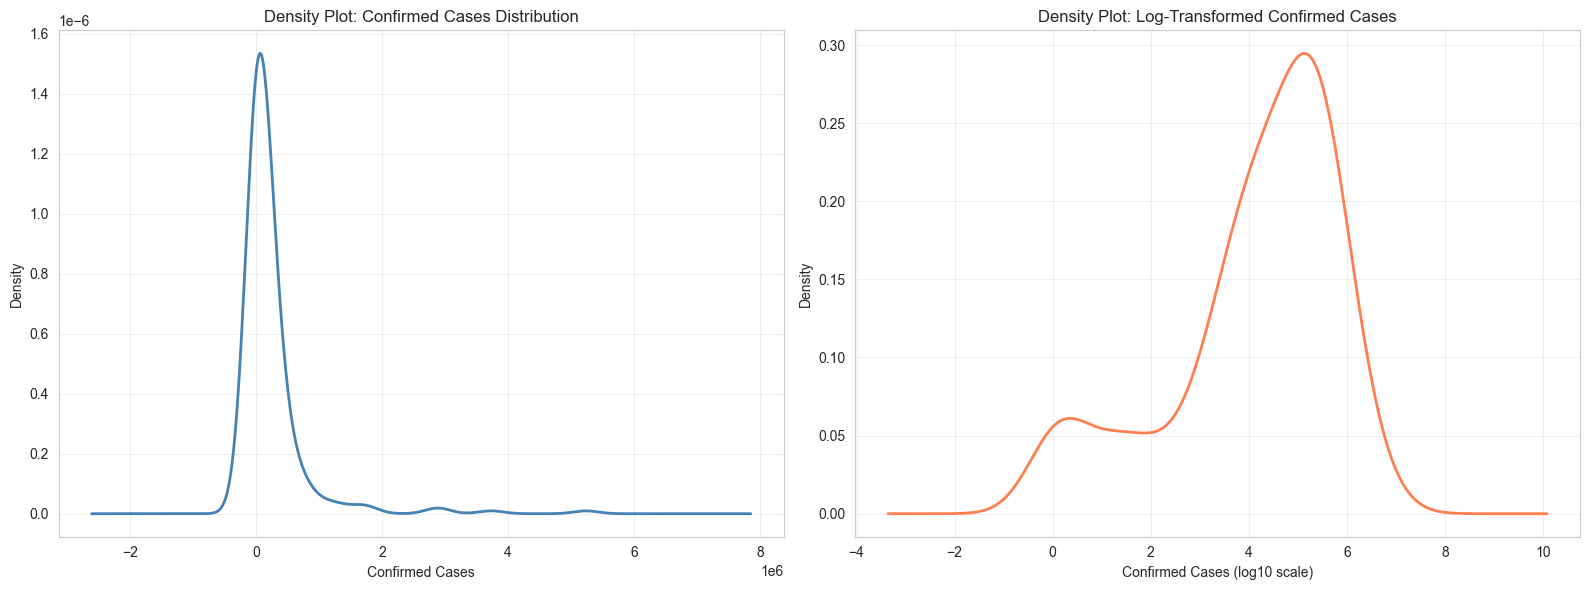

In [9]:
# Density plots (KDE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confirmed cases density
latest_data[latest_data['Confirmed'] > 0]['Confirmed'].plot(kind='density', ax=axes[0], 
                                                              color='steelblue', linewidth=2)
axes[0].set_xlabel('Confirmed Cases')
axes[0].set_ylabel('Density')
axes[0].set_title('Density Plot: Confirmed Cases Distribution')
axes[0].grid(True, alpha=0.3)

# Log-scale density for better visualization
latest_data[latest_data['Confirmed'] > 0]['Confirmed'].apply(np.log10).plot(
    kind='density', ax=axes[1], color='coral', linewidth=2)
axes[1].set_xlabel('Confirmed Cases (log10 scale)')
axes[1].set_ylabel('Density')
axes[1].set_title('Density Plot: Log-Transformed Confirmed Cases')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_01_density_plot.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Y1-02: Time Series Analysis

**Objective:** Show trends over time for confirmed, deaths, and recovered cases

## 2.1 Global Time Series

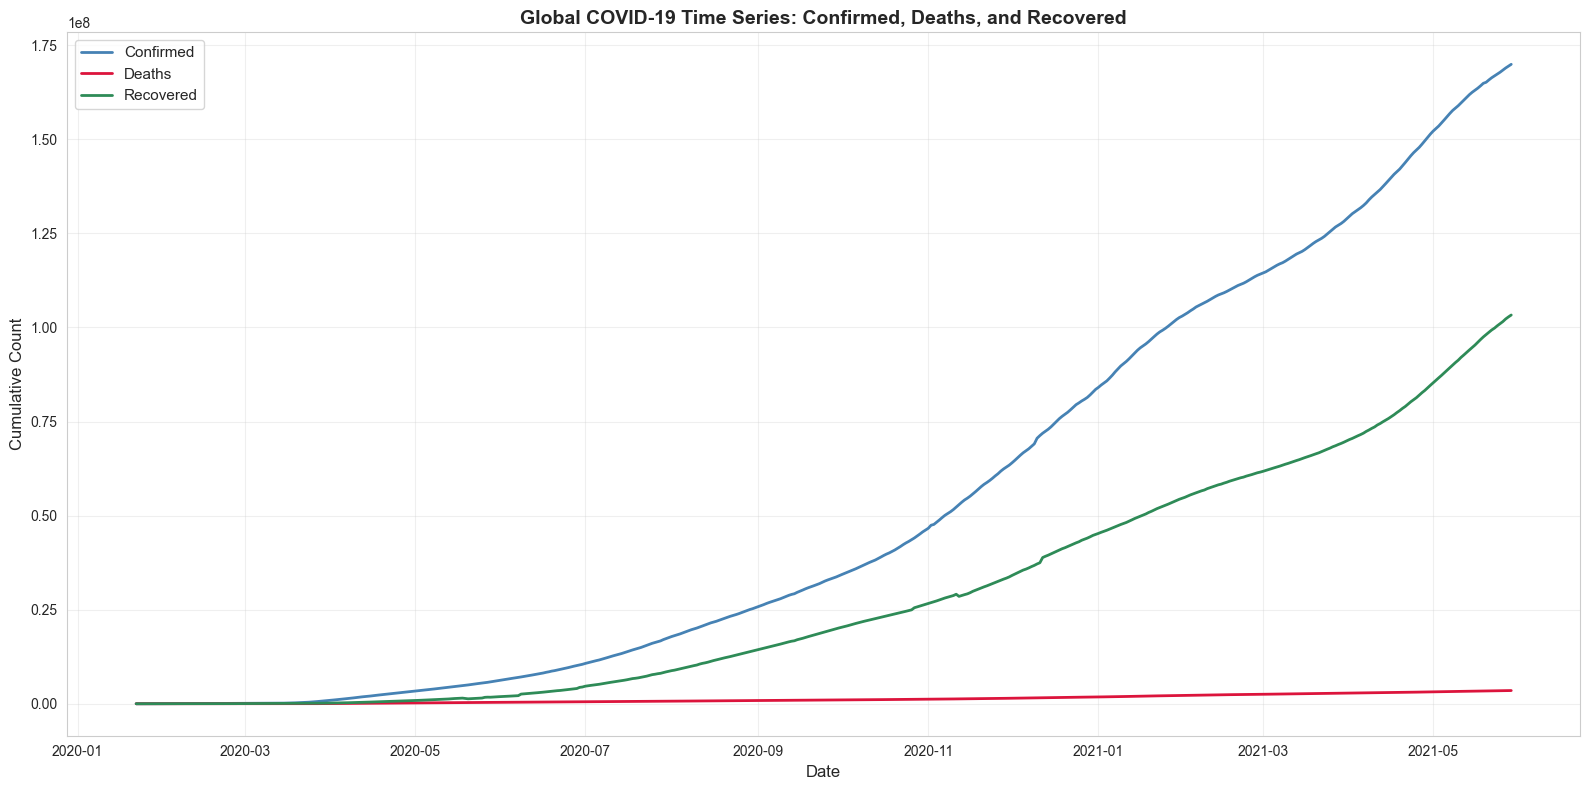

In [10]:
# Aggregate global totals by date
global_ts = df.groupby('ObservationDate')[['Confirmed', 'Deaths', 'Recovered']].sum()

# Plot time series
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(global_ts.index, global_ts['Confirmed'], label='Confirmed', linewidth=2, color='steelblue')
ax.plot(global_ts.index, global_ts['Deaths'], label='Deaths', linewidth=2, color='crimson')
ax.plot(global_ts.index, global_ts['Recovered'], label='Recovered', linewidth=2, color='seagreen')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Count', fontsize=12)
ax.set_title('Global COVID-19 Time Series: Confirmed, Deaths, and Recovered', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_02_global_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## 2.2 Multi-Country Comparison

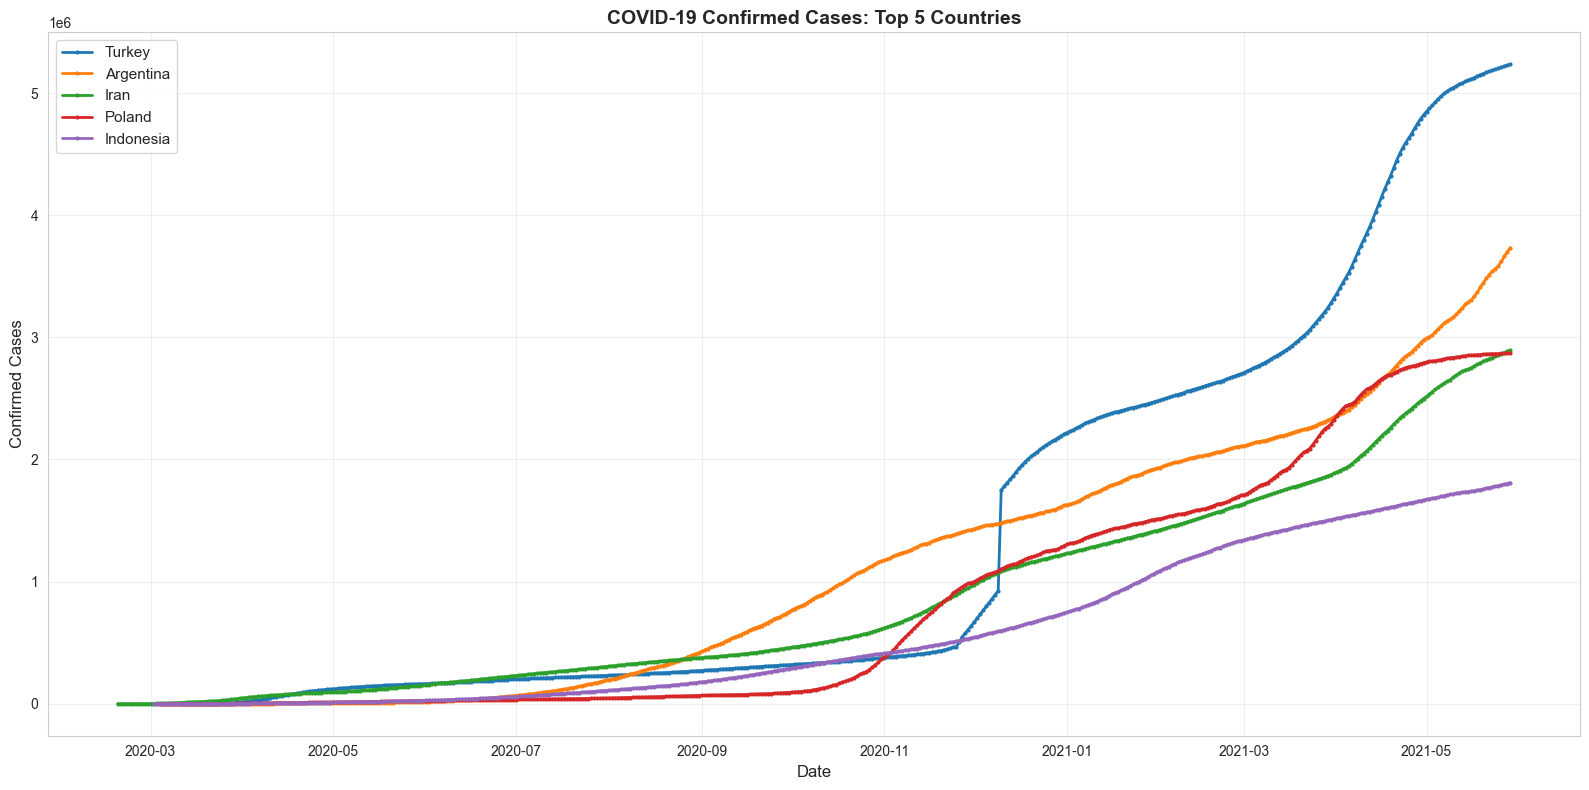

In [11]:
# Select top 5 countries by confirmed cases
top_countries = latest_data.nlargest(5, 'Confirmed')['Country/Region'].values

fig, ax = plt.subplots(figsize=(16, 8))

for country in top_countries:
    country_data = df[df['Country/Region'] == country].groupby('ObservationDate')['Confirmed'].sum()
    ax.plot(country_data.index, country_data.values, label=country, linewidth=2, marker='o', markersize=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Confirmed Cases', fontsize=12)
ax.set_title(f'COVID-19 Confirmed Cases: Top {len(top_countries)} Countries', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_02_country_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
# Y1-03: Trend and Recovery Analysis

**Objective:** Analyze seasonality patterns in deaths and recovery rates by country/region

## 3.1 Seasonality in Deaths

In [12]:
# TODO: Add seasonality decomposition analysis
# Consider using statsmodels.tsa.seasonal.seasonal_decompose

print("Seasonality analysis - Implementation required")

Seasonality analysis - Implementation required


## 3.2 Recovery Rate Analysis

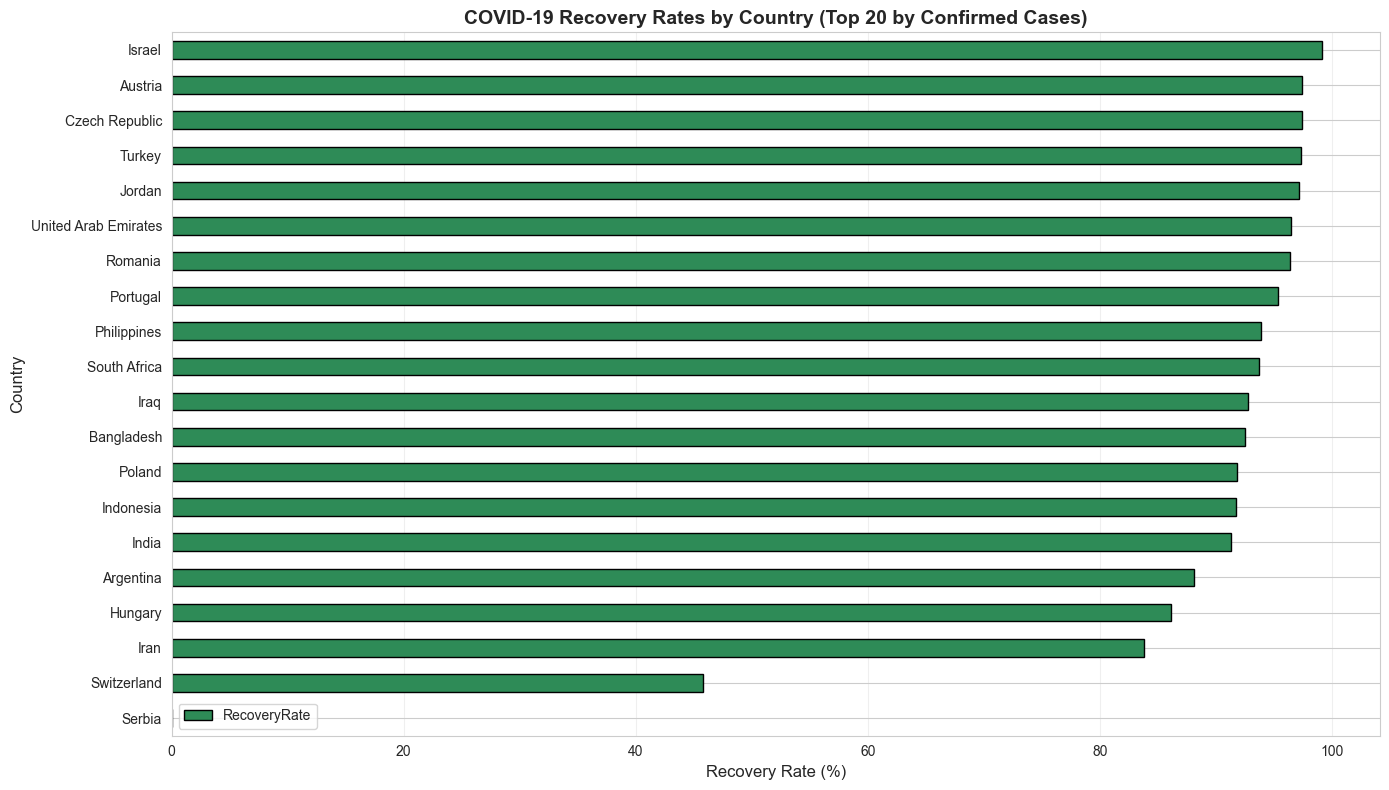

In [13]:
# Calculate recovery rate by country
recovery_analysis = latest_data[latest_data['Confirmed'] > 1000].copy()
recovery_analysis['RecoveryRate'] = (recovery_analysis['Recovered'] / recovery_analysis['Confirmed'] * 100)
recovery_analysis = recovery_analysis.nlargest(20, 'Confirmed')

# Plot recovery rates
fig, ax = plt.subplots(figsize=(14, 8))

recovery_analysis.sort_values('RecoveryRate', ascending=True).plot(
    x='Country/Region', y='RecoveryRate', kind='barh', ax=ax, color='seagreen', edgecolor='black'
)

ax.set_xlabel('Recovery Rate (%)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('COVID-19 Recovery Rates by Country (Top 20 by Confirmed Cases)', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_03_recovery_rates.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.3 Case Fatality Rate (CFR) Analysis

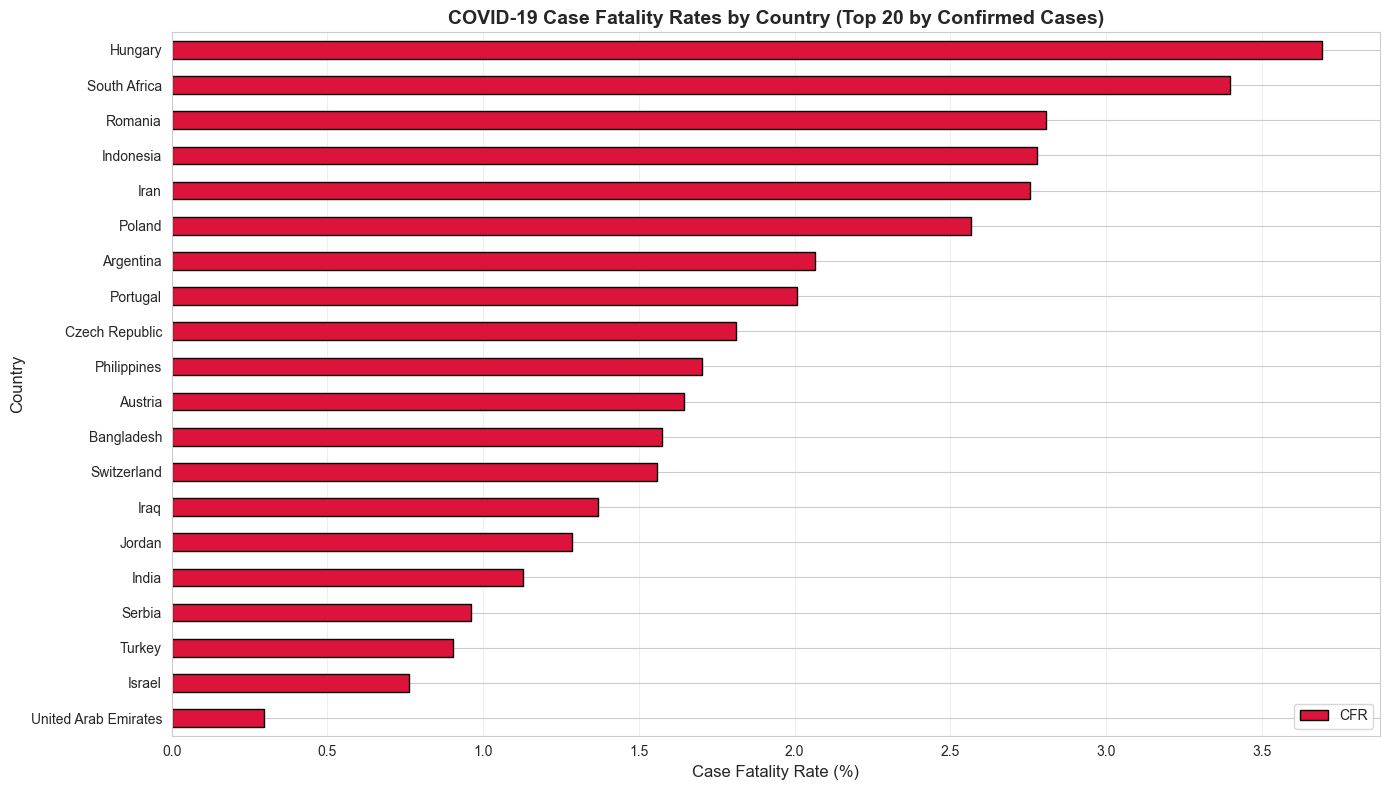

In [14]:
# Calculate CFR by country
cfr_analysis = latest_data[latest_data['Confirmed'] > 1000].copy()
cfr_analysis['CFR'] = (cfr_analysis['Deaths'] / cfr_analysis['Confirmed'] * 100)
cfr_analysis = cfr_analysis.nlargest(20, 'Confirmed')

# Plot CFR
fig, ax = plt.subplots(figsize=(14, 8))

cfr_analysis.sort_values('CFR', ascending=True).plot(
    x='Country/Region', y='CFR', kind='barh', ax=ax, color='crimson', edgecolor='black'
)

ax.set_xlabel('Case Fatality Rate (%)', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('COVID-19 Case Fatality Rates by Country (Top 20 by Confirmed Cases)', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'y1_03_case_fatality_rates.png', dpi=300, bbox_inches='tight')
plt.show()

---
## Summary

**Phase 1 Deliverables:**
- ✅ Y1-01: Distribution analysis (histogram, box plot, density)
- ✅ Y1-02: Time series plots
- ✅ Y1-03: Trend and recovery analysis

**Key Findings:**
- [Document your findings here]

**Next Steps:**
- Proceed to Phase 2 advanced visualizations